## Step 1: Loading the Datasets

This step loads the cleaned BI dataset and the prescription dataset from the Colab environment. These files provide the predictor variables and the final prescription labels that will be used in the implementation.

In [ ]:
# Installing the Excel reader package
!pip install -q openpyxl

# Importing the required libraries
import pandas as pd
import numpy as np

# Loading the datasets from the Colab environment
bi_df = pd.read_excel("BI_data.xlsx", engine="openpyxl")
prescription_df = pd.read_excel("prescription.xlsx", engine="openpyxl")

# Inspecting the dataset dimensions
print("BI dataset shape:", bi_df.shape)
print("Prescription dataset shape:", prescription_df.shape)

# Previewing the first rows of each dataset
print("\nBI dataset preview:")
display(bi_df.head())

print("\nPrescription dataset preview:")
display(prescription_df.head())

# Inspecting the column names
print("\nBI dataset columns:")
print(bi_df.columns.tolist())

print("\nPrescription dataset columns:")
print(prescription_df.columns.tolist())

BI dataset shape: (840, 70)
Prescription dataset shape: (840, 2)

BI dataset preview:


,coding,gender,age_categories,screening_va_ldu_both_logmar,screening_va_ldu_re_logmar,screening_va_ldu_le_logmar,screening_va_lda_both_logmar,screening_va_lda_re_logmar,screening_va_lda_le_logmar,screening_va_sdu_both_logmar,...,dot_va_dot_short_le_logmar,dot_va_dot_short_both_logmar,pres_lens_long_re_categories,pres_lens_long_le_categories,pres_lens_short_re_categories,pres_lens_short_le_categories,pupillary_distance_categories,rg_test_re_categories,rg_test_le_categories,dot_time_taken_minutes
0,NB001,F,Young Adults,0.802,0.799,0.8,NaN,NaN,NaN,0.37,...,NaN,NaN,Moderate Myopia,Moderate Myopia,NaN,NaN,Step 2 – Medium,Balanced,Balanced,12
1,NB002,F,Teenagers,0.802,0.903,0.9,NaN,NaN,NaN,0.00,...,NaN,NaN,Moderate Myopia,Mild Myopia,NaN,NaN,Step 3 – Wide,Undercorrected,Undercorrected,10
2,NB003,F,Young Adults,0.398,0.398,0.6,0.2,0.7,0.7,0.22,...,0.273,NaN,NaN,NaN,Medium Add,Medium Add,Step 2 – Medium,NaN,NaN,8
3,NB004,M,Middle-aged Adults,2.000,2.3,2.3,NaN,NaN,NaN,0.12,...,NaN,NaN,Moderate Myopia,Moderate Myopia,NaN,NaN,Step 1 – Narrow,Undercorrected,Undercorrected,10
4,NB005,M,Middle-aged Adults,0.602,0.602,0.6,NaN,NaN,NaN,0.12,...,0.273,0.273,Mild Myopia,Mild Myopia,Low Add,Low Add,Step 1 – Narrow,Undercorrected,Undercorrected,12



Prescription dataset preview:


,coding,final_prescription
0,NB001,DOT
1,NB002,FULL
2,NB003,FULL
3,NB004,DOT
4,NB005,FULL



BI dataset columns:
[' coding', 'gender', 'age_categories', 'screening_va_ldu_both_logmar', 'screening_va_ldu_re_logmar', 'screening_va_ldu_le_logmar', 'screening_va_lda_both_logmar', 'screening_va_lda_re_logmar', 'screening_va_lda_le_logmar', 'screening_va_sdu_both_logmar', 'screening_va_sdu_re_logmar', 'screening_va_sdu_le_logmar', ' screening_va_sda_both_logmar', 'screening_va_sda_re_logmar', 'screening_va_sda_le_logmar', 'screening_va_ph_re_logmar', 'screening_va_ph_le_logmar', 'screening_va_plano_re_logmar', 'screening_va_plano_le_logmar', 'screening_va_plano_both_logmar', 'full_auto_re_sphere', 'full_auto_re_cylinder', 'full_auto_re_axis', 'full_auto_le_sphere', 'full_auto_le_cylinder', 'full_auto_le_axis', 'full_va_ldu_both_logmar', 'full_va_ldu_re_logmar', 'full_va_ldu_le_logmar', 'full_va_lda_both_logmar', 'full_va_lda_re_logmar', 'full_va_lda_le_logmar', 'full_va_sdu_both_logmar ', 'full_va_sdu_re_logmar', 'full_va_sdu_le_logmar', 'full_va_sda_both_logmar', 'full_va_sda_re_l

The datasets have loaded successfully into the Colab environment. The cleaned BI dataset contains 840 rows and 70 columns, showing that it holds a rich set of participant-level predictor variables for the implementation. The prescription dataset contains 840 rows and 2 columns, confirming that it provides the participant identifier and the final prescription label required for the target variable. The matching row counts across the two files suggest that the datasets are aligned at participant level and are likely to merge cleanly using the `coding` field. The preview also confirms that the BI dataset already contains cleaned demographic and logMAR-based screening features, while the prescription dataset clearly defines the two target classes, `DOT` and `FULL`. This gives a clean and stable foundation for the next step, which will involve standardizing the key columns and preparing the datasets for merging.

## Step 2: Standardizing and Merging the Datasets

This step is standardizing the key columns in the two datasets and merging them using the participant ID. The aim is creating one master dataset that combines the predictor variables with the final prescription labels for the next stages of exploratory analysis and modeling.

In [ ]:
# Standardizing the column names
bi_df.columns = (
    bi_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

prescription_df.columns = (
    prescription_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Standardizing the participant ID field
bi_df["coding"] = bi_df["coding"].astype(str).str.strip().str.upper()
prescription_df["coding"] = prescription_df["coding"].astype(str).str.strip().str.upper()

# Standardizing the target labels
prescription_df["final_prescription"] = (
    prescription_df["final_prescription"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Inspecting the class distribution before merging
print("Final prescription distribution:")
print(prescription_df["final_prescription"].value_counts(dropna=False))

# Merging the datasets using the participant ID
merged_df = pd.merge(
    bi_df,
    prescription_df,
    on="coding",
    how="inner"
)

# Inspecting the merged dataset
print("\nMerged dataset shape:", merged_df.shape)
print("Unique participant IDs in merged dataset:", merged_df["coding"].nunique())

# Checking for duplicated participant IDs
duplicate_count = merged_df["coding"].duplicated().sum()
print("Duplicate participant IDs after merging:", duplicate_count)

# Previewing the merged dataset
print("\nMerged dataset preview:")
display(merged_df.head())

# Inspecting the final columns after merging
print("\nMerged dataset columns:")
print(merged_df.columns.tolist())

Final prescription distribution:
final_prescription
DOT     433
FULL    387
NAN      20
Name: count, dtype: int64

Merged dataset shape: (840, 71)
Unique participant IDs in merged dataset: 840
Duplicate participant IDs after merging: 0

Merged dataset preview:


,coding,gender,age_categories,screening_va_ldu_both_logmar,screening_va_ldu_re_logmar,screening_va_ldu_le_logmar,screening_va_lda_both_logmar,screening_va_lda_re_logmar,screening_va_lda_le_logmar,screening_va_sdu_both_logmar,...,dot_va_dot_short_both_logmar,pres_lens_long_re_categories,pres_lens_long_le_categories,pres_lens_short_re_categories,pres_lens_short_le_categories,pupillary_distance_categories,rg_test_re_categories,rg_test_le_categories,dot_time_taken_minutes,final_prescription
0,NB001,F,Young Adults,0.802,0.799,0.8,NaN,NaN,NaN,0.37,...,NaN,Moderate Myopia,Moderate Myopia,NaN,NaN,Step 2 – Medium,Balanced,Balanced,12,DOT
1,NB002,F,Teenagers,0.802,0.903,0.9,NaN,NaN,NaN,0.00,...,NaN,Moderate Myopia,Mild Myopia,NaN,NaN,Step 3 – Wide,Undercorrected,Undercorrected,10,FULL
2,NB003,F,Young Adults,0.398,0.398,0.6,0.2,0.7,0.7,0.22,...,NaN,NaN,NaN,Medium Add,Medium Add,Step 2 – Medium,NaN,NaN,8,FULL
3,NB004,M,Middle-aged Adults,2.000,2.3,2.3,NaN,NaN,NaN,0.12,...,NaN,Moderate Myopia,Moderate Myopia,NaN,NaN,Step 1 – Narrow,Undercorrected,Undercorrected,10,DOT
4,NB005,M,Middle-aged Adults,0.602,0.602,0.6,NaN,NaN,NaN,0.12,...,0.273,Mild Myopia,Mild Myopia,Low Add,Low Add,Step 1 – Narrow,Undercorrected,Undercorrected,12,FULL



Merged dataset columns:
['coding', 'gender', 'age_categories', 'screening_va_ldu_both_logmar', 'screening_va_ldu_re_logmar', 'screening_va_ldu_le_logmar', 'screening_va_lda_both_logmar', 'screening_va_lda_re_logmar', 'screening_va_lda_le_logmar', 'screening_va_sdu_both_logmar', 'screening_va_sdu_re_logmar', 'screening_va_sdu_le_logmar', 'screening_va_sda_both_logmar', 'screening_va_sda_re_logmar', 'screening_va_sda_le_logmar', 'screening_va_ph_re_logmar', 'screening_va_ph_le_logmar', 'screening_va_plano_re_logmar', 'screening_va_plano_le_logmar', 'screening_va_plano_both_logmar', 'full_auto_re_sphere', 'full_auto_re_cylinder', 'full_auto_re_axis', 'full_auto_le_sphere', 'full_auto_le_cylinder', 'full_auto_le_axis', 'full_va_ldu_both_logmar', 'full_va_ldu_re_logmar', 'full_va_ldu_le_logmar', 'full_va_lda_both_logmar', 'full_va_lda_re_logmar', 'full_va_lda_le_logmar', 'full_va_sdu_both_logmar', 'full_va_sdu_re_logmar', 'full_va_sdu_le_logmar', 'full_va_sda_both_logmar', 'full_va_sda_re_

The standardization and merging step has worked well. The merged dataset now contains 840 rows and 71 columns, confirming that all participant records from the cleaned BI dataset have been successfully aligned with the prescription dataset using the `coding` field. The absence of duplicate participant IDs after merging shows that the participant identifier is consistent and reliable for modeling. The class distribution indicates that the target variable is reasonably balanced, with 433 participants in the `DOT` class and 387 in the `FULL` class, although 20 missing prescription labels are still present and will need to be handled before model training. Overall, this result confirms that the merged dataset is structurally sound and ready for the next stage, which will involve inspecting missing values and identifying the variables that are suitable for exploratory analysis and model preparation.

## Step 3: Inspecting the Merged Dataset

This step is examining the merged dataset to understand its structure before modeling. The aim is identifying missing values, confirming variable types, and getting a quick view of the target variable so that the next stage of exploratory analysis and feature preparation can be done from a clear and informed position.

In [ ]:
# Inspecting the data types of the merged dataset
print("Merged dataset data types:")
print(merged_df.dtypes)

# Inspecting the missing values in each column
missing_summary = (
    merged_df.isnull()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column_name", "missing_count"]

print("\nTop 20 columns by missing values:")
display(missing_summary.head(20))

# Inspecting the percentage of missing values
missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(merged_df) * 100
)

print("\nTop 20 columns by missing percentage:")
display(missing_summary.head(20))

# Inspecting the target variable more closely
print("\nTarget variable distribution including missing values:")
display(merged_df["final_prescription"].value_counts(dropna=False))

# Inspecting the number of complete and incomplete target rows
print("\nRows with non-missing target:", merged_df["final_prescription"].notna().sum())
print("Rows with missing target:", merged_df["final_prescription"].isna().sum())

# Inspecting the number of numerical and categorical columns
numerical_columns = merged_df.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = merged_df.select_dtypes(exclude=["number"]).columns.tolist()

print("\nNumber of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

print("\nSample numerical columns:")
print(numerical_columns[:15])

print("\nSample categorical columns:")
print(categorical_columns[:15])

Merged dataset data types:
coding                            object
gender                            object
age_categories                    object
screening_va_ldu_both_logmar     float64
screening_va_ldu_re_logmar        object
                                  ...   
pupillary_distance_categories     object
rg_test_re_categories             object
rg_test_le_categories             object
dot_time_taken_minutes            object
final_prescription                object
Length: 71, dtype: object

Top 20 columns by missing values:


,column_name,missing_count
0,dot_va_plano_re_logmar,831
1,dot_va_lda_re_logmar,824
2,dot_va_lda_both_logmar,824
3,dot_va_lda_le_logmar,824
4,dot_va_sda_re_logmar,813
5,dot_va_sda_le_logmar,813
6,dot_va_sda_both_logmar,812
7,screening_va_lda_le_logmar,810
8,screening_va_lda_both_logmar,809
9,screening_va_lda_re_logmar,808



Top 20 columns by missing percentage:


,column_name,missing_count,missing_percentage
0,dot_va_plano_re_logmar,831,98.928571
1,dot_va_lda_re_logmar,824,98.095238
2,dot_va_lda_both_logmar,824,98.095238
3,dot_va_lda_le_logmar,824,98.095238
4,dot_va_sda_re_logmar,813,96.785714
5,dot_va_sda_le_logmar,813,96.785714
6,dot_va_sda_both_logmar,812,96.666667
7,screening_va_lda_le_logmar,810,96.428571
8,screening_va_lda_both_logmar,809,96.309524
9,screening_va_lda_re_logmar,808,96.190476



Target variable distribution including missing values:


,count
final_prescription,
DOT,433
FULL,387
NAN,20



Rows with non-missing target: 840
Rows with missing target: 0

Number of numerical columns: 58
Number of categorical columns: 13

Sample numerical columns:
['screening_va_ldu_both_logmar', 'screening_va_ldu_le_logmar', 'screening_va_lda_both_logmar', 'screening_va_lda_re_logmar', 'screening_va_lda_le_logmar', 'screening_va_sdu_both_logmar', 'screening_va_sdu_re_logmar', 'screening_va_sdu_le_logmar', 'screening_va_sda_both_logmar', 'screening_va_sda_re_logmar', 'screening_va_sda_le_logmar', 'screening_va_ph_re_logmar', 'screening_va_ph_le_logmar', 'screening_va_plano_re_logmar', 'screening_va_plano_le_logmar']

Sample categorical columns:
['coding', 'gender', 'age_categories', 'screening_va_ldu_re_logmar', 'pres_lens_long_re_categories', 'pres_lens_long_le_categories', 'pres_lens_short_re_categories', 'pres_lens_short_le_categories', 'pupillary_distance_categories', 'rg_test_re_categories', 'rg_test_le_categories', 'dot_time_taken_minutes', 'final_prescription']


## Step 4: Preparing the Modeling Dataset

This step is preparing the merged dataset for modeling without discarding meaningful missing values. The aim is retaining all valid participant records, isolating the target variable, separating the predictor variables, and creating a clean working dataset that preserves the structure of the cleaned data for the next stages of exploratory analysis and preprocessing.

In [ ]:
# Inspecting the target variable for missing values
print("Rows with non-missing target:", merged_df["final_prescription"].notna().sum())
print("Rows with missing target:", merged_df["final_prescription"].isna().sum())

# Creating the modeling dataset by keeping rows with valid target labels only
model_df = merged_df[merged_df["final_prescription"].notna()].copy()

# Inspecting the modeling dataset shape
print("\nModeling dataset shape:", model_df.shape)

# Inspecting the updated target distribution
print("\nUpdated target distribution:")
display(model_df["final_prescription"].value_counts(dropna=False))

# Defining the columns that are not being used as predictors
excluded_columns = [
    "coding",
    "final_prescription"
]

# Selecting the predictor columns
feature_columns = [col for col in model_df.columns if col not in excluded_columns]

# Creating the feature matrix and target vector
X = model_df[feature_columns].copy()
y = model_df["final_prescription"].copy()

# Inspecting the feature matrix and target vector shapes
print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# Previewing the feature matrix
print("\nFeature matrix preview:")
display(X.head())

# Previewing the target vector
print("\nTarget vector preview:")
display(y.head())

# Inspecting the predictor column names
print("\nPredictor columns:")
print(feature_columns)

# Inspecting the missing values in the feature matrix without dropping them
feature_missing_summary = (
    X.isnull()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

feature_missing_summary.columns = ["column_name", "missing_count"]
feature_missing_summary["missing_percentage"] = (
    feature_missing_summary["missing_count"] / len(X) * 100
)

print("\nTop 20 predictor columns by missing values:")
display(feature_missing_summary.head(20))

Rows with non-missing target: 840
Rows with missing target: 0

Modeling dataset shape: (840, 71)

Updated target distribution:


,count
final_prescription,
DOT,433
FULL,387
NAN,20



Feature matrix shape: (840, 69)
Target vector shape: (840,)

Feature matrix preview:


,gender,age_categories,screening_va_ldu_both_logmar,screening_va_ldu_re_logmar,screening_va_ldu_le_logmar,screening_va_lda_both_logmar,screening_va_lda_re_logmar,screening_va_lda_le_logmar,screening_va_sdu_both_logmar,screening_va_sdu_re_logmar,...,dot_va_dot_short_le_logmar,dot_va_dot_short_both_logmar,pres_lens_long_re_categories,pres_lens_long_le_categories,pres_lens_short_re_categories,pres_lens_short_le_categories,pupillary_distance_categories,rg_test_re_categories,rg_test_le_categories,dot_time_taken_minutes
0,F,Young Adults,0.802,0.799,0.8,NaN,NaN,NaN,0.37,0.37,...,NaN,NaN,Moderate Myopia,Moderate Myopia,NaN,NaN,Step 2 – Medium,Balanced,Balanced,12
1,F,Teenagers,0.802,0.903,0.9,NaN,NaN,NaN,0.00,0.00,...,NaN,NaN,Moderate Myopia,Mild Myopia,NaN,NaN,Step 3 – Wide,Undercorrected,Undercorrected,10
2,F,Young Adults,0.398,0.398,0.6,0.2,0.7,0.7,0.22,0.12,...,0.273,NaN,NaN,NaN,Medium Add,Medium Add,Step 2 – Medium,NaN,NaN,8
3,M,Middle-aged Adults,2.000,2.3,2.3,NaN,NaN,NaN,0.12,0.12,...,NaN,NaN,Moderate Myopia,Moderate Myopia,NaN,NaN,Step 1 – Narrow,Undercorrected,Undercorrected,10
4,M,Middle-aged Adults,0.602,0.602,0.6,NaN,NaN,NaN,0.12,0.12,...,0.273,0.273,Mild Myopia,Mild Myopia,Low Add,Low Add,Step 1 – Narrow,Undercorrected,Undercorrected,12



Target vector preview:


,final_prescription
0,DOT
1,FULL
2,FULL
3,DOT
4,FULL



Predictor columns:
['gender', 'age_categories', 'screening_va_ldu_both_logmar', 'screening_va_ldu_re_logmar', 'screening_va_ldu_le_logmar', 'screening_va_lda_both_logmar', 'screening_va_lda_re_logmar', 'screening_va_lda_le_logmar', 'screening_va_sdu_both_logmar', 'screening_va_sdu_re_logmar', 'screening_va_sdu_le_logmar', 'screening_va_sda_both_logmar', 'screening_va_sda_re_logmar', 'screening_va_sda_le_logmar', 'screening_va_ph_re_logmar', 'screening_va_ph_le_logmar', 'screening_va_plano_re_logmar', 'screening_va_plano_le_logmar', 'screening_va_plano_both_logmar', 'full_auto_re_sphere', 'full_auto_re_cylinder', 'full_auto_re_axis', 'full_auto_le_sphere', 'full_auto_le_cylinder', 'full_auto_le_axis', 'full_va_ldu_both_logmar', 'full_va_ldu_re_logmar', 'full_va_ldu_le_logmar', 'full_va_lda_both_logmar', 'full_va_lda_re_logmar', 'full_va_lda_le_logmar', 'full_va_sdu_both_logmar', 'full_va_sdu_re_logmar', 'full_va_sdu_le_logmar', 'full_va_sda_both_logmar', 'full_va_sda_re_logmar', 'full_

,column_name,missing_count,missing_percentage
0,dot_va_plano_re_logmar,831,98.928571
1,dot_va_lda_both_logmar,824,98.095238
2,dot_va_lda_re_logmar,824,98.095238
3,dot_va_lda_le_logmar,824,98.095238
4,dot_va_sda_le_logmar,813,96.785714
5,dot_va_sda_re_logmar,813,96.785714
6,dot_va_sda_both_logmar,812,96.666667
7,screening_va_lda_le_logmar,810,96.428571
8,screening_va_lda_both_logmar,809,96.309524
9,screening_va_lda_re_logmar,808,96.190476


## Step 5: Exploring the Modeling Dataset

At this point, we are examining the modeling dataset to understand the selected predictors and the target variable before preprocessing. The focus here is on checking the target balance, summarizing the numerical and categorical variables, and identifying the main patterns that will guide feature preparation and model building.

Target distribution:


,count
final_prescription,
DOT,433
FULL,387
NAN,20


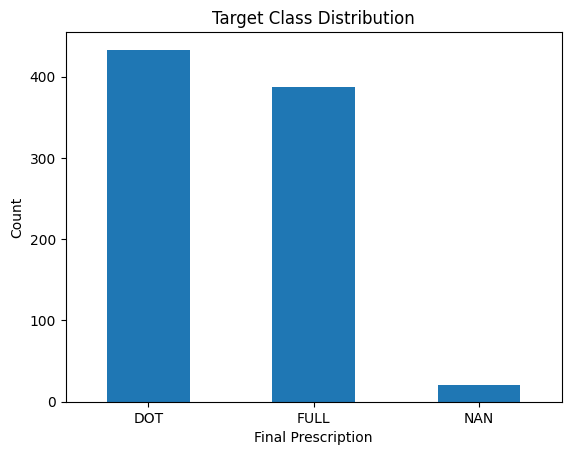

Number of numerical predictor columns: 58
Number of categorical predictor columns: 11

Sample numerical predictor columns:
['screening_va_ldu_both_logmar', 'screening_va_ldu_le_logmar', 'screening_va_lda_both_logmar', 'screening_va_lda_re_logmar', 'screening_va_lda_le_logmar', 'screening_va_sdu_both_logmar', 'screening_va_sdu_re_logmar', 'screening_va_sdu_le_logmar', 'screening_va_sda_both_logmar', 'screening_va_sda_re_logmar', 'screening_va_sda_le_logmar', 'screening_va_ph_re_logmar', 'screening_va_ph_le_logmar', 'screening_va_plano_re_logmar', 'screening_va_plano_le_logmar']

Sample categorical predictor columns:
['gender', 'age_categories', 'screening_va_ldu_re_logmar', 'pres_lens_long_re_categories', 'pres_lens_long_le_categories', 'pres_lens_short_re_categories', 'pres_lens_short_le_categories', 'pupillary_distance_categories', 'rg_test_re_categories', 'rg_test_le_categories', 'dot_time_taken_minutes']

Summary of numerical predictor columns:


,count,mean,std,min,25%,50%,75%,max
screening_va_ldu_both_logmar,805.0,0.389142,0.319265,0.000,0.200000,0.301000,0.602000,3.000
screening_va_ldu_le_logmar,746.0,0.442225,0.365711,0.000,0.200000,0.400000,0.600000,3.000
screening_va_lda_both_logmar,31.0,0.325806,0.303280,0.000,0.050000,0.200000,0.600000,0.900
screening_va_lda_re_logmar,32.0,0.396875,0.297825,0.000,0.100000,0.400000,0.600000,1.000
screening_va_lda_le_logmar,30.0,0.486667,0.501538,0.000,0.125000,0.400000,0.700000,2.600
screening_va_sdu_both_logmar,756.0,0.222923,0.183244,0.000,0.120000,0.220000,0.370000,3.000
screening_va_sdu_re_logmar,751.0,0.241971,0.185639,0.000,0.120000,0.220000,0.370000,3.000
screening_va_sdu_le_logmar,744.0,0.249812,0.234166,0.000,0.120000,0.220000,0.370000,3.000
screening_va_sda_both_logmar,40.0,0.090250,0.117549,0.000,0.000000,0.000000,0.145000,0.370
screening_va_sda_re_logmar,40.0,0.113500,0.147745,0.000,0.000000,0.060000,0.220000,0.600



Summary of categorical predictor columns:


,column_name,unique_values,missing_count
2,screening_va_ldu_re_logmar,30,21
10,dot_time_taken_minutes,29,5
6,pres_lens_short_le_categories,8,337
5,pres_lens_short_re_categories,7,335
4,pres_lens_long_le_categories,7,551
7,pupillary_distance_categories,6,157
0,gender,5,2
1,age_categories,5,0
3,pres_lens_long_re_categories,5,553
8,rg_test_re_categories,4,183



Value counts for gender:


...

,count
rg_test_re_categories,
Overcorrected,337
Balanced,215
NaN,183
Undercorrected,105



Value counts for rg_test_le_categories:


,count
rg_test_le_categories,
Overcorrected,270
Undercorrected,236
NaN,184
Balanced,150



Correlation matrix preview:


,screening_va_ldu_both_logmar,screening_va_ldu_le_logmar,screening_va_lda_both_logmar,screening_va_lda_re_logmar,screening_va_lda_le_logmar,screening_va_sdu_both_logmar,screening_va_sdu_re_logmar,screening_va_sdu_le_logmar,screening_va_sda_both_logmar,screening_va_sda_re_logmar
screening_va_ldu_both_logmar,1.000000,0.862743,0.282810,0.215151,0.353181,-0.111855,-0.149781,-0.128422,-0.135180,-0.138922
screening_va_ldu_le_logmar,0.862743,1.000000,0.276512,0.211685,0.488966,-0.142708,-0.182223,-0.066880,-0.176178,-0.167547
screening_va_lda_both_logmar,0.282810,0.276512,1.000000,0.879495,0.746504,-0.090926,-0.077058,-0.050447,0.323489,0.270446
screening_va_lda_re_logmar,0.215151,0.211685,0.879495,1.000000,0.669830,-0.138978,-0.126121,-0.112708,0.273406,0.386470
screening_va_lda_le_logmar,0.353181,0.488966,0.746504,0.669830,1.000000,-0.059191,-0.050605,-0.033098,0.164353,0.030567
screening_va_sdu_both_logmar,-0.111855,-0.142708,-0.090926,-0.138978,-0.059191,1.000000,0.940583,0.720992,0.158491,0.078434
screening_va_sdu_re_logmar,-0.149781,-0.182223,-0.077058,-0.126121,-0.050605,0.940583,1.000000,0.722152,0.130830,0.091283
screening_va_sdu_le_logmar,-0.128422,-0.066880,-0.050447,-0.112708,-0.033098,0.720992,0.722152,1.000000,0.145155,0.105037
screening_va_sda_both_logmar,-0.135180,-0.176178,0.323489,0.273406,0.164353,0.158491,0.130830,0.145155,1.000000,0.709652
screening_va_sda_re_logmar,-0.138922,-0.167547,0.270446,0.386470,0.030567,0.078434,0.091283,0.105037,0.709652,1.000000


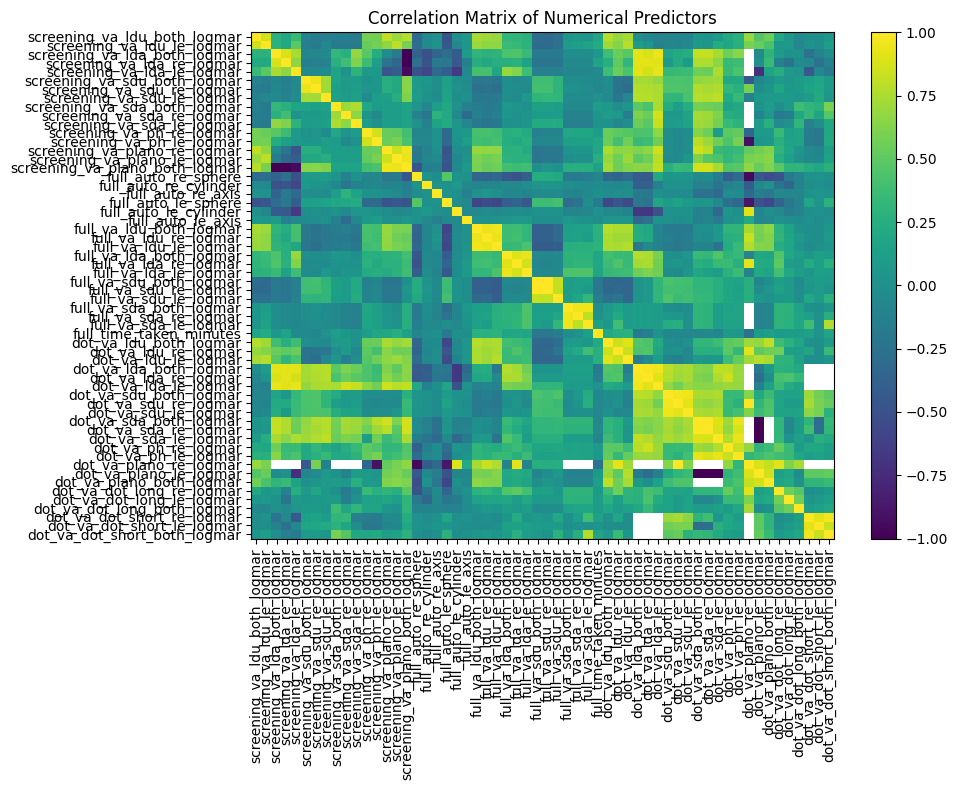

In [ ]:
import matplotlib.pyplot as plt

# Inspecting the target distribution
print("Target distribution:")
display(y.value_counts())

# Plotting the target distribution
y.value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Final Prescription")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Identifying the numerical and categorical predictor columns
numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Number of numerical predictor columns:", len(numerical_columns))
print("Number of categorical predictor columns:", len(categorical_columns))

print("\nSample numerical predictor columns:")
print(numerical_columns[:15])

print("\nSample categorical predictor columns:")
print(categorical_columns[:15])

# Summarizing the numerical predictor columns
print("\nSummary of numerical predictor columns:")
display(X[numerical_columns].describe().T)

# Summarizing the categorical predictor columns
categorical_summary = pd.DataFrame({
    "column_name": categorical_columns,
    "unique_values": [X[col].nunique(dropna=False) for col in categorical_columns],
    "missing_count": [X[col].isna().sum() for col in categorical_columns]
})

print("\nSummary of categorical predictor columns:")
display(categorical_summary.sort_values(by="unique_values", ascending=False))

# Inspecting the first few category levels for each categorical column
for col in categorical_columns[:10]:
    print(f"\nValue counts for {col}:")
    display(X[col].value_counts(dropna=False).head(10))

# Inspecting the correlation among numerical predictor columns
if len(numerical_columns) > 1:
    correlation_matrix = X[numerical_columns].corr()

    print("\nCorrelation matrix preview:")
    display(correlation_matrix.iloc[:10, :10])

    plt.figure(figsize=(10, 8))
    plt.imshow(correlation_matrix, aspect="auto")
    plt.colorbar()
    plt.title("Correlation Matrix of Numerical Predictors")
    plt.xticks(range(len(numerical_columns)), numerical_columns, rotation=90)
    plt.yticks(range(len(numerical_columns)), numerical_columns)
    plt.tight_layout()
    plt.show()

The exploratory review shows that the modeling dataset is broadly usable, but it still needs careful feature handling before model training. The target variable is fairly balanced, with 433 participants in the `DOT` class and 387 in the `FULL` class, although 20 records still have missing prescription labels and should be excluded from supervised learning :contentReference[oaicite:0]{index=0}

The predictor set is dominated by numerical variables, with 58 numerical columns and 11 categorical columns, indicating that the implementation will rely heavily on quantitative screening and refraction measurements rather than on text-like attributes :contentReference[oaicite:1]{index=1} The numerical summaries also show large differences in completeness across features. Some variables such as `screening_va_ldu_both_logmar`, `screening_va_sdu_both_logmar`, `full_va_ldu_re_logmar`, and `dot_va_sdu_both_logmar` have strong coverage and are likely to be useful candidates for modeling, while several near-vision and special-condition variables have very small counts and may contribute little unless handled carefully :contentReference[oaicite:2]{index=2}

Among the categorical predictors, the structure appears meaningful but uneven. Core variables such as `gender`, `age_categories`, `pupillary_distance_categories`, and the RG test categories are interpretable and potentially useful, while several prescription category variables contain substantial missingness that may reflect structural absence rather than data error :contentReference[oaicite:3]{index=3} The repeated occurrence of visually similar labels in `gender` suggests that some categories may still need final standardization before encoding :contentReference[oaicite:4]{index=4}

The correlation preview also suggests that a number of numerical features are strongly related, especially within the screening visual acuity groups, which means multicollinearity is likely present and feature selection will need to be done carefully before fitting the models :contentReference[oaicite:5]{index=5}

## Step 6: Refining the Predictor Set and Preparing the Preprocessing Pipeline

The exploratory analysis has shown that the merged dataset is rich enough for modeling, but it also revealed several issues that need to be handled before training begins. First, rows with missing target labels cannot be used in supervised learning because the model needs known outcomes during training. For that reason, only records with valid `DOT` or `FULL` labels are being retained. Second, the predictor set still contains variables that should not enter the model directly, such as participant identifiers, because they do not carry clinical meaning and may introduce noise rather than useful signal. Third, the dataset contains both numerical and categorical predictors, and they need different preprocessing strategies. The numerical variables are being imputed with the median because many of them are clinical measurements where the median is more robust to skewness and outliers than the mean. The categorical variables are being imputed with a constant label such as `"Missing"` so that structurally absent values are preserved rather than discarded. Finally, the categorical variables are being one-hot encoded to convert them into a form that machine learning models can process without imposing false numerical order. Completing this step will give us a clean, modeling-ready feature matrix that preserves meaningful information while minimizing avoidable noise and data loss.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer

# Retaining only the rows with valid target labels
model_df = merged_df[merged_df["final_prescription"].notna()].copy()

# Standardizing the target labels again for safety
model_df["final_prescription"] = (
    model_df["final_prescription"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Retaining only the valid target classes
model_df = model_df[model_df["final_prescription"].isin(["DOT", "FULL"])].copy()

# Inspecting the modeling dataset shape
print("Modeling dataset shape:", model_df.shape)

# Inspecting the cleaned target distribution
print("\nTarget distribution after retaining valid labels:")
display(model_df["final_prescription"].value_counts())

# Defining the columns that are not being used as predictors
excluded_columns = [
    "coding",
    "final_prescription"
]

# Creating the predictor set and target vector
X = model_df.drop(columns=excluded_columns)
y = model_df["final_prescription"].copy()

# Identifying the numerical and categorical predictor columns
numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = X.select_dtypes(exclude=["number"]).columns.tolist()

# Inspecting the variable groups
print("\nNumber of numerical predictor columns:", len(numerical_columns))
print("Number of categorical predictor columns:", len(categorical_columns))

print("\nFirst 15 numerical predictor columns:")
print(numerical_columns[:15])

print("\nFirst 15 categorical predictor columns:")
print(categorical_columns[:15])

# Building the preprocessing pipeline for numerical predictors
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Building the preprocessing pipeline for categorical predictors
categorical_transformer = Pipeline(steps=[
    ("to_string", FunctionTransformer(lambda x: x.astype(str), feature_names_out='one-to-one')),
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combining the preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

# Fitting the preprocessing pipeline and transforming the predictor matrix
X_processed = preprocessor.fit_transform(X)

# Inspecting the processed matrix shape
print("\nProcessed feature matrix shape:", X_processed.shape)

# Extracting the processed feature names where possible
feature_names = preprocessor.get_feature_names_out()

print("\nNumber of processed features:", len(feature_names))
print("\nFirst 30 processed feature names:")
print(feature_names[:30])

# Saving the modeling inputs for the next stage
print("\nFeature matrix ready for train-test splitting and model training.")

Modeling dataset shape: (820, 71)

Target distribution after retaining valid labels:


,count
final_prescription,
DOT,433
FULL,387



Number of numerical predictor columns: 58
Number of categorical predictor columns: 11

First 15 numerical predictor columns:
['screening_va_ldu_both_logmar', 'screening_va_ldu_le_logmar', 'screening_va_lda_both_logmar', 'screening_va_lda_re_logmar', 'screening_va_lda_le_logmar', 'screening_va_sdu_both_logmar', 'screening_va_sdu_re_logmar', 'screening_va_sdu_le_logmar', 'screening_va_sda_both_logmar', 'screening_va_sda_re_logmar', 'screening_va_sda_le_logmar', 'screening_va_ph_re_logmar', 'screening_va_ph_le_logmar', 'screening_va_plano_re_logmar', 'screening_va_plano_le_logmar']

First 15 categorical predictor columns:
['gender', 'age_categories', 'screening_va_ldu_re_logmar', 'pres_lens_long_re_categories', 'pres_lens_long_le_categories', 'pres_lens_short_re_categories', 'pres_lens_short_le_categories', 'pupillary_distance_categories', 'rg_test_re_categories', 'rg_test_le_categories', 'dot_time_taken_minutes']

Processed feature matrix shape: (820, 168)

Number of processed features:

The preprocessing stage has worked as intended. After removing only the records with missing target labels, the modeling dataset now contains 820 observations and 71 columns, which provides a sufficient sample for binary classification. The target variable remains reasonably balanced, with 433 `DOT` cases and 387 `FULL` cases, so there is no severe class imbalance at this stage.

The predictor structure is also clear. The dataset contains 58 numerical variables and 11 categorical variables, confirming that the model will rely mainly on quantitative clinical and screening measurements, with a smaller set of demographic and categorized prescription-related features. The preprocessing pipeline has expanded these predictors into 168 processed features after imputation and one-hot encoding. This increase is expected, since each categorical variable is being broken into multiple binary indicators while the numerical variables are being retained in their original form after median imputation.

Overall, this result shows that the data is now in a model-ready format. The next logical step is splitting the processed data into training and testing sets, then fitting baseline classification models so that we can evaluate predictive performance before moving to model comparison and refinement.

## Step 7: Training the Baseline Models

With the predictors now transformed into a model-ready matrix, the next stage is establishing baseline performance. The purpose here is splitting the data into training and testing sets, fitting a small set of interpretable and widely used classification models, and evaluating them on unseen data. Starting with baseline models is important because it gives a defensible reference point for the rest of the implementation. It helps us understand how well the current feature set is performing before introducing more complex methods, and it makes later model comparisons more meaningful. At this stage, logistic regression, decision tree, and random forest are being used because they provide a balanced combination of simplicity, interpretability, and predictive strength.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd

# Encoding the target variable
y_encoded = y.map({"DOT": 0, "FULL": 1})

# Splitting the processed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Inspecting the split dimensions
print("Training feature matrix shape:", X_train.shape)
print("Testing feature matrix shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

# Defining the baseline models
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Training the models and collecting the evaluation metrics
results = []

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["DOT", "FULL"]))

# Creating the comparison table
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

print("\nBaseline model comparison:")
display(results_df)

Training feature matrix shape: (656, 168)
Testing feature matrix shape: (164, 168)
Training target shape: (656,)
Testing target shape: (164,)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
-------------------
Confusion Matrix:
[[63 24]
 [31 46]]

Classification Report:
              precision    recall  f1-score   support

         DOT       0.67      0.72      0.70        87
        FULL       0.66      0.60      0.63        77

    accuracy                           0.66       164
   macro avg       0.66      0.66      0.66       164
weighted avg       0.66      0.66      0.66       164


Decision Tree
-------------
Confusion Matrix:
[[42 45]
 [30 47]]

Classification Report:
              precision    recall  f1-score   support

         DOT       0.58      0.48      0.53        87
        FULL       0.51      0.61      0.56        77

    accuracy                           0.54       164
   macro avg       0.55      0.55      0.54       164
weighted avg       0.55      0.54      0.54       164


Random Forest
-------------
Confusion Matrix:
[[61 26]
 [36 41]]

Classification Report:
              precision    recall  f1-score   support

         

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.664634,0.657143,0.597403,0.625850
2,Random Forest,0.621951,0.611940,0.532468,0.569444
1,Decision Tree,0.542683,0.510870,0.610390,0.556213


The baseline modeling results provide a useful starting point, but they also show that the current feature set and preprocessing pipeline are not yet producing strong predictive separation between the two classes. The train-test split was carried out cleanly, with 656 observations used for training and 164 for testing, which is appropriate for an initial benchmark.

Among the three baseline models, logistic regression performed best overall, achieving the highest accuracy and the strongest F1-score among the models tested. Its confusion matrix also shows the most balanced behavior, although misclassification remains noticeable in both directions. This suggests that the model is learning some meaningful structure from the data, but the separation between the `DOT` and `FULL` classes is still only moderate.

The decision tree produced the weakest performance, with lower accuracy and a less stable confusion pattern, which may indicate overfitting and weaker generalization to unseen data. The random forest improved on the decision tree, but it still did not outperform logistic regression. This suggests that the current predictor representation may not yet be allowing the tree-based models to capture stronger signal.

Overall, the implementation is working correctly from a technical perspective, but the predictive performance is still moderate. The next step should focus on improving the preprocessing and feature space, especially through scaling, more careful variable selection, and possibly reducing redundant or weak predictors before re-training the models.

## Step 8: Improving the Preprocessing Pipeline and Re-training the Models

The baseline results suggest that the current implementation is functioning correctly, but the predictor space still needs refinement before a stronger model can emerge. The main improvement at this stage is scaling the numerical variables so that models such as logistic regression can learn under more stable numerical conditions. At the same time, the preprocessing pipeline is being kept consistent across all models so that the comparison remains fair. Re-training the baseline models after this improvement will show whether the moderate performance observed earlier was partly caused by the way the predictors were being prepared rather than by the data itself.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd

# Retaining only the rows with valid target labels
model_df = merged_df[merged_df["final_prescription"].notna()].copy()

# Standardizing the target labels again for safety
model_df["final_prescription"] = (
    model_df["final_prescription"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Retaining only the valid target classes
model_df = model_df[model_df["final_prescription"].isin(["DOT", "FULL"])].copy()

# Defining the columns that are not being used as predictors
excluded_columns = [
    "coding",
    "final_prescription"
]

# Creating the predictor set and target vector
X = model_df.drop(columns=excluded_columns)
y = model_df["final_prescription"].map({"DOT": 0, "FULL": 1})

# Identifying the numerical and categorical predictor columns
numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = X.select_dtypes(exclude=["number"]).columns.tolist()

# Building the improved preprocessing pipeline for numerical predictors
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Building the preprocessing pipeline for categorical predictors
categorical_transformer = Pipeline(steps=[
    ("to_string", FunctionTransformer(lambda x: x.astype(str), feature_names_out='one-to-one')),
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combining the preprocessing steps
improved_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

# Splitting the data into training and testing sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training predictor shape:", X_train_raw.shape)
print("Testing predictor shape:", X_test_raw.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

# Defining the improved baseline models
improved_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Training and evaluating the models under the improved preprocessing pipeline
improved_results = []

for model_name, model in improved_models.items():
    model_pipeline = Pipeline(steps=[
        ("preprocessor", improved_preprocessor),
        ("classifier", model)
    ])

    model_pipeline.fit(X_train_raw, y_train)
    y_pred = model_pipeline.predict(X_test_raw)

    improved_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["DOT", "FULL"]))

# Creating the improved results table
improved_results_df = pd.DataFrame(improved_results).sort_values(by="F1 Score", ascending=False)

print("\nImproved model comparison:")
display(improved_results_df)

Training predictor shape: (656, 69)
Testing predictor shape: (164, 69)
Training target shape: (656,)
Testing target shape: (164,)

Logistic Regression
-------------------
Confusion Matrix:
[[63 24]
 [34 43]]

Classification Report:
              precision    recall  f1-score   support

         DOT       0.65      0.72      0.68        87
        FULL       0.64      0.56      0.60        77

    accuracy                           0.65       164
   macro avg       0.65      0.64      0.64       164
weighted avg       0.65      0.65      0.64       164


Decision Tree
-------------
Confusion Matrix:
[[45 42]
 [30 47]]

Classification Report:
              precision    recall  f1-score   support

         DOT       0.60      0.52      0.56        87
        FULL       0.53      0.61      0.57        77

    accuracy                           0.56       164
   macro avg       0.56      0.56      0.56       164
weighted avg       0.57      0.56      0.56       164


Random Forest
---------

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.646341,0.641791,0.558442,0.597222
2,Random Forest,0.615854,0.600000,0.545455,0.571429
1,Decision Tree,0.560976,0.528090,0.610390,0.566265


The re-trained models show that the improved preprocessing pipeline has not produced a meaningful performance gain over the earlier baseline. Logistic regression remains the best-performing model, with an accuracy of about 64.6% and an F1-score of about 0.60 for the `FULL` class. This confirms that, among the models tested so far, logistic regression is still providing the most stable and balanced prediction pattern.

The decision tree remains the weakest model, with lower overall accuracy and a more uneven confusion pattern. Although it captures some `FULL` cases reasonably well, its performance is still inconsistent and suggests weaker generalization. The random forest performs better than the decision tree, but it still does not surpass logistic regression. This indicates that the current predictor set may still contain redundancy, noise, or weak signal that is limiting the benefit of more flexible tree-based models.

An important observation is that scaling the numerical variables did not substantially improve performance. This suggests that the main limitation may no longer be the numerical conditioning of the data, but rather the composition and quality of the feature set itself. In other words, the next improvement is more likely to come from feature refinement than from additional preprocessing of the same variables.

Overall, the implementation is technically sound and the models are training correctly, but predictive performance is still moderate. The most defensible next step is to refine the predictor space by removing weak, sparse, or redundant variables and then re-train the models on the reduced feature set.

## Step 9: Refining the Feature Set and Re-training the Models

The results obtained so far suggest that the main limitation is no longer the basic preprocessing pipeline, but the predictor space itself. A large number of variables are currently being passed into the models, yet the earlier exploration showed that some of them are highly sparse, some are structurally missing for many participants, and several are likely to be strongly correlated with one another. Using all of them at once may be diluting the useful signal and reducing the models’ ability to generalize well.

At this stage, the goal is tightening the feature space before re-training the models. This is being done in a controlled way by removing predictors with very high missingness, preserving variables that still have clear clinical meaning, and keeping a smaller set of features that is easier to interpret and less likely to introduce noise. Doing this is important because it gives the models a more focused learning space and allows us to test whether the moderate performance seen so far is being caused by weak or redundant variables rather than by the underlying data itself.

Once the refined feature set has been defined, the same modeling pipeline will be used again so that the comparison remains fair. This will help determine whether reducing the predictor space improves predictive performance and produces a more stable recommendation system.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd

# Retaining only the rows with valid target labels
refined_df = merged_df[merged_df["final_prescription"].notna()].copy()

# Standardizing the target labels again for safety
refined_df["final_prescription"] = (
    refined_df["final_prescription"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Retaining only the valid target classes
refined_df = refined_df[refined_df["final_prescription"].isin(["DOT", "FULL"])].copy()

# Removing the non-predictor columns
excluded_columns = ["coding", "final_prescription"]
candidate_X = refined_df.drop(columns=excluded_columns).copy()
candidate_y = refined_df["final_prescription"].map({"DOT": 0, "FULL": 1})

# Inspecting the missingness of the predictor columns
missing_rates = candidate_X.isnull().mean().sort_values(ascending=False)

# Retaining the columns with at most 50 percent missingness
selected_columns = missing_rates[missing_rates <= 0.50].index.tolist()

# Creating the refined predictor matrix
X_refined = candidate_X[selected_columns].copy()
y_refined = candidate_y.copy()

print("Original predictor count:", candidate_X.shape[1])
print("Refined predictor count:", X_refined.shape[1])

# Identifying the numerical and categorical columns in the refined predictor set
numerical_columns_refined = X_refined.select_dtypes(include=["number"]).columns.tolist()
categorical_columns_refined = X_refined.select_dtypes(exclude=["number"]).columns.tolist()

print("\nNumber of refined numerical predictor columns:", len(numerical_columns_refined))
print("Number of refined categorical predictor columns:", len(categorical_columns_refined))

print("\nRefined predictor columns:")
print(X_refined.columns.tolist())

# Building the preprocessing pipeline for the refined predictors
numerical_transformer_refined = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_refined = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("to_string", FunctionTransformer(lambda x: x.astype(str), feature_names_out='one-to-one')),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

refined_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer_refined, numerical_columns_refined),
        ("cat", categorical_transformer_refined, categorical_columns_refined)
    ]
)

# Splitting the refined data into training and testing sets
X_train_refined, X_test_refined, y_train_refined, y_test_refined = train_test_split(
    X_refined,
    y_refined,
    test_size=0.2,
    random_state=42,
    stratify=y_refined
)

print("\nTraining predictor shape:", X_train_refined.shape)
print("Testing predictor shape:", X_test_refined.shape)
print("Training target shape:", y_train_refined.shape)
print("Testing target shape:", y_test_refined.shape)

# Defining the models for re-training
refined_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Training and evaluating the models on the refined feature set
refined_results = []

for model_name, model in refined_models.items():
    refined_pipeline = Pipeline(steps=[
        ("preprocessor", refined_preprocessor),
        ("classifier", model)
    ])

    refined_pipeline.fit(X_train_refined, y_train_refined)
    y_pred_refined = refined_pipeline.predict(X_test_refined)

    refined_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_refined, y_pred_refined),
        "Precision": precision_score(y_test_refined, y_pred_refined),
        "Recall": recall_score(y_test_refined, y_pred_refined),
        "F1 Score": f1_score(y_test_refined, y_pred_refined)
    })

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_refined, y_pred_refined))
    print("\nClassification Report:")
    print(classification_report(y_test_refined, y_pred_refined, target_names=["DOT", "FULL"]))

# Creating the refined comparison table
refined_results_df = pd.DataFrame(refined_results).sort_values(by="F1 Score", ascending=False)

print("\nRefined model comparison:")
display(refined_results_df)

Original predictor count: 69
Refined predictor count: 39

Number of refined numerical predictor columns: 30
Number of refined categorical predictor columns: 9

Refined predictor columns:
['full_va_lda_both_logmar', 'full_va_lda_le_logmar', 'full_va_lda_re_logmar', 'dot_va_dot_short_both_logmar', 'dot_va_dot_short_le_logmar', 'dot_va_dot_short_re_logmar', 'pres_lens_short_le_categories', 'pres_lens_short_re_categories', 'rg_test_le_categories', 'rg_test_re_categories', 'full_auto_re_axis', 'full_auto_re_cylinder', 'full_auto_le_axis', 'pupillary_distance_categories', 'full_auto_le_cylinder', 'dot_va_sdu_re_logmar', 'dot_va_sdu_le_logmar', 'full_va_sdu_re_logmar', 'screening_va_sdu_le_logmar', 'full_va_sdu_both_logmar', 'full_va_sdu_le_logmar', 'screening_va_ldu_le_logmar', 'screening_va_sdu_re_logmar', 'screening_va_sdu_both_logmar', 'dot_va_ldu_both_logmar', 'dot_va_ldu_re_logmar', 'dot_va_ldu_le_logmar', 'screening_va_ldu_both_logmar', 'full_time_taken_minutes', 'full_va_ldu_both_logm

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.646341,0.655738,0.519481,0.579710
1,Decision Tree,0.548780,0.518072,0.558442,0.537500
2,Random Forest,0.591463,0.575758,0.493506,0.531469


The refined feature selection reduced the predictor space from 69 variables to 39, with the retained set consisting of 30 numerical predictors and 9 categorical predictors. This shows that the refinement step successfully removed a substantial portion of the sparse or high-missingness variables while preserving a clinically meaningful set of screening, refraction, prescription, timing, and demographic features.

However, the re-trained models show that this reduction did not improve predictive performance. Logistic regression remains the best-performing model, but its results are nearly unchanged, with accuracy remaining at about 64.6% and the F1-score for the `FULL` class dropping slightly to about 0.58. The confusion matrix also shows that misclassification is still substantial, especially for the `FULL` cases, where many participants are still being predicted as `DOT`.

The decision tree and random forest also remain weaker than logistic regression, with both models showing lower accuracy and lower F1-scores after feature reduction. This suggests that the weaker variables were not the main cause of the moderate performance seen earlier. Instead, the current data may contain overlapping class patterns that are not easily separable with the available features, or the retained features may still include redundancy that is not being resolved by simple missingness-based selection alone.

Overall, the implementation remains technically sound, but the modeling evidence now suggests that further gains are unlikely to come from broad missingness filtering alone. The next step should focus on a more targeted improvement strategy, such as selecting features based on model importance or domain relevance, and then testing whether a smaller, more purposeful feature set can improve separation between the `DOT` and `FULL` classes.

## Step 10: Selecting the Most Informative Features and Re-training the Models

The earlier results suggest that the main issue is no longer basic preprocessing or broad feature reduction, but the quality of the predictors being fed into the models. At this point, the goal is narrowing the feature space more deliberately by retaining variables that contribute the most useful signal to the classification task. This is important because a smaller and more purposeful predictor set can reduce redundancy, improve interpretability, and sometimes strengthen generalization. To do this, a random forest model is first being used to estimate feature importance after preprocessing. The strongest transformed features are then identified, and the models are re-trained using only that reduced subset. This allows us to test whether a more focused feature space improves separation between the `DOT` and `FULL` classes.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.feature_selection import SelectFromModel
import pandas as pd
import numpy as np

# Retaining only the rows with valid target labels
feature_df = merged_df[merged_df["final_prescription"].notna()].copy()

# Standardizing the target labels again for safety
feature_df["final_prescription"] = (
    feature_df["final_prescription"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Retaining only the valid target classes
feature_df = feature_df[feature_df["final_prescription"].isin(["DOT", "FULL"])].copy()

# Removing the non-predictor columns
excluded_columns = ["coding", "final_prescription"]
X_feature = feature_df.drop(columns=excluded_columns).copy()
y_feature = feature_df["final_prescription"].map({"DOT": 0, "FULL": 1})

# Identifying the numerical and categorical predictor columns
numerical_columns_feature = X_feature.select_dtypes(include=["number"]).columns.tolist()
categorical_columns_feature = X_feature.select_dtypes(exclude=["number"]).columns.tolist()

# Building the preprocessing pipeline
numerical_transformer_feature = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_feature = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("to_string", FunctionTransformer(lambda x: x.astype(str), feature_names_out='one-to-one')),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

feature_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer_feature, numerical_columns_feature),
        ("cat", categorical_transformer_feature, categorical_columns_feature)
    ]
)

# Splitting the data into training and testing sets
X_train_feature_raw, X_test_feature_raw, y_train_feature, y_test_feature = train_test_split(
    X_feature,
    y_feature,
    test_size=0.2,
    random_state=42,
    stratify=y_feature
)

print("Training predictor shape:", X_train_feature_raw.shape)
print("Testing predictor shape:", X_test_feature_raw.shape)

# Fitting the preprocessor on the training set
X_train_feature_processed = feature_preprocessor.fit_transform(X_train_feature_raw)
X_test_feature_processed = feature_preprocessor.transform(X_test_feature_raw)

# Extracting the processed feature names
processed_feature_names = feature_preprocessor.get_feature_names_out()

print("\nProcessed training matrix shape:", X_train_feature_processed.shape)
print("Processed testing matrix shape:", X_test_feature_processed.shape)

# Training a random forest model for feature importance estimation
feature_selector_model = RandomForestClassifier(random_state=42)
feature_selector_model.fit(X_train_feature_processed, y_train_feature)

# Extracting the feature importances
feature_importances = pd.DataFrame({
    "feature_name": processed_feature_names,
    "importance": feature_selector_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 30 most important transformed features:")
display(feature_importances.head(30))

# Selecting the important features using the median importance threshold
selector = SelectFromModel(
    feature_selector_model,
    threshold="median",
    prefit=True
)

X_train_selected = selector.transform(X_train_feature_processed)
X_test_selected = selector.transform(X_test_feature_processed)

selected_feature_mask = selector.get_support()
selected_feature_names = processed_feature_names[selected_feature_mask]

print("\nSelected feature count:", len(selected_feature_names))
print("\nTop selected features:")
print(selected_feature_names[:30])

print("\nSelected training matrix shape:", X_train_selected.shape)
print("Selected testing matrix shape:", X_test_selected.shape)

# Defining the models for re-training on the selected features
selected_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Training and evaluating the models on the selected features
selected_results = []

for model_name, model in selected_models.items():
    model.fit(X_train_selected, y_train_feature)
    y_pred_selected = model.predict(X_test_selected)

    selected_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_feature, y_pred_selected),
        "Precision": precision_score(y_test_feature, y_pred_selected),
        "Recall": recall_score(y_test_feature, y_pred_selected),
        "F1 Score": f1_score(y_test_feature, y_pred_selected)
    })

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_feature, y_pred_selected))
    print("\nClassification Report:")
    print(classification_report(y_test_feature, y_pred_selected, target_names=["DOT", "FULL"]))

# Creating the comparison table
selected_results_df = pd.DataFrame(selected_results).sort_values(by="F1 Score", ascending=False)

print("\nModel comparison after targeted feature selection:")
display(selected_results_df)

Training predictor shape: (656, 69)
Testing predictor shape: (164, 69)

Processed training matrix shape: (656, 162)
Processed testing matrix shape: (164, 162)

Top 30 most important transformed features:


,feature_name,importance
16,num__full_auto_re_sphere,0.036136
20,num__full_auto_le_cylinder,0.035286
18,num__full_auto_re_axis,0.035188
21,num__full_auto_le_axis,0.034856
19,num__full_auto_le_sphere,0.032502
17,num__full_auto_re_cylinder,0.030005
34,num__full_time_taken_minutes,0.026294
37,num__dot_va_ldu_le_logmar,0.022344
119,cat__pupillary_distance_categories_Missing,0.022008
24,num__full_va_ldu_le_logmar,0.021769



Selected feature count: 81

Top selected features:
['num__screening_va_ldu_both_logmar' 'num__screening_va_ldu_le_logmar'
 'num__screening_va_sdu_both_logmar' 'num__screening_va_sdu_re_logmar'
 'num__screening_va_sdu_le_logmar' 'num__screening_va_ph_re_logmar'
 'num__screening_va_ph_le_logmar' 'num__screening_va_plano_re_logmar'
 'num__screening_va_plano_le_logmar' 'num__screening_va_plano_both_logmar'
 'num__full_auto_re_sphere' 'num__full_auto_re_cylinder'
 'num__full_auto_re_axis' 'num__full_auto_le_sphere'
 'num__full_auto_le_cylinder' 'num__full_auto_le_axis'
 'num__full_va_ldu_both_logmar' 'num__full_va_ldu_re_logmar'
 'num__full_va_ldu_le_logmar' 'num__full_va_lda_both_logmar'
 'num__full_va_lda_re_logmar' 'num__full_va_lda_le_logmar'
 'num__full_va_sdu_both_logmar' 'num__full_va_sdu_re_logmar'
 'num__full_va_sdu_le_logmar' 'num__full_time_taken_minutes'
 'num__dot_va_ldu_both_logmar' 'num__dot_va_ldu_re_logmar'
 'num__dot_va_ldu_le_logmar' 'num__dot_va_sdu_both_logmar']

Selec

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.615854,0.609375,0.506494,0.553191
2,Random Forest,0.591463,0.571429,0.519481,0.544218
1,Decision Tree,0.506098,0.477273,0.545455,0.509091


The targeted feature selection step successfully reduced the transformed feature space from 162 to 81 features, and the importance ranking shows that the strongest signal is coming mainly from full autorefractor measurements, full visual acuity measures, selected DOT visual acuity measures, and a few clinically relevant categorical indicators such as pupillary distance and short-lens prescription categories. This suggests that the model is drawing most of its predictive information from a relatively concentrated subset of the original feature space.

However, the re-trained models show that this more focused selection did not improve predictive performance. Logistic regression remains the strongest model, but its performance has dropped slightly, with accuracy falling to about 61.6% and the F1-score for the `FULL` class falling to about 0.55. The confusion matrix also shows that a substantial number of `FULL` cases are still being classified as `DOT`, indicating that the two classes are still not being separated clearly enough by the selected features.

The random forest and decision tree models also remain weaker than logistic regression, and neither of them shows any evidence of meaningful improvement after the targeted selection step. This indicates that the issue is not simply the presence of weak variables, but likely a deeper overlap in the underlying class structure. In practical terms, the available predictors appear to carry only moderate discriminatory power for distinguishing between `DOT` and `FULL`.

Overall, the implementation is still technically sound, and the experiments have now established a clear pattern: logistic regression is the most stable model, but performance remains moderate even after scaling, broad refinement, and targeted feature selection. At this point, the most defensible next move is not further aggressive feature trimming, but trying one stronger boosting-based classifier and then locking the best-performing model for interpretation and documentation.

## Step 11: Training a Stronger Boosting-Based Model

The results so far have established a consistent pattern. The implementation pipeline is working correctly, logistic regression has remained the most stable model, and repeated rounds of broad and targeted feature trimming have not produced a meaningful gain. At this stage, continuing with more cleaning would likely add complexity without changing the overall picture. A more useful next move is testing a stronger boosting-based classifier that can capture nonlinear relationships and feature interactions more effectively than the baseline models. This is important because if the current predictors contain signal that simpler models are not fully using, a boosting model has a better chance of extracting it. The purpose of this step is therefore evaluating whether a more powerful learner can improve the classification of `DOT` and `FULL` before we settle on the final model for interpretation and documentation.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Retaining only the rows with valid target labels
boost_df = merged_df[merged_df["final_prescription"].notna()].copy()

# Standardizing the target labels again for safety
boost_df["final_prescription"] = (
    boost_df["final_prescription"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Retaining only the valid target classes
boost_df = boost_df[boost_df["final_prescription"].isin(["DOT", "FULL"])].copy()

# Defining the predictor matrix and target vector
excluded_columns = ["coding", "final_prescription"]
X_boost = boost_df.drop(columns=excluded_columns).copy()
y_boost = boost_df["final_prescription"].map({"DOT": 0, "FULL": 1})

# Identifying the numerical and categorical columns
numerical_columns_boost = X_boost.select_dtypes(include=["number"]).columns.tolist()
categorical_columns_boost = X_boost.select_dtypes(exclude=["number"]).columns.tolist()

# Building the preprocessing pipeline
numerical_transformer_boost = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_boost = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("to_string", FunctionTransformer(lambda x: x.astype(str), feature_names_out='one-to-one')),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

boost_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer_boost, numerical_columns_boost),
        ("cat", categorical_transformer_boost, categorical_columns_boost)
    ]
)

# Splitting the data into training and testing sets
X_train_boost, X_test_boost, y_train_boost, y_test_boost = train_test_split(
    X_boost,
    y_boost,
    test_size=0.2,
    random_state=42,
    stratify=y_boost
)

print("Training predictor shape:", X_train_boost.shape)
print("Testing predictor shape:", X_test_boost.shape)
print("Training target shape:", y_train_boost.shape)
print("Testing target shape:", y_test_boost.shape)

# Defining the boosting model
boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Building the full modeling pipeline
boosting_pipeline = Pipeline(steps=[
    ("preprocessor", boost_preprocessor),
    ("classifier", boosting_model)
])

# Training the model
boosting_pipeline.fit(X_train_boost, y_train_boost)

# Generating predictions
y_pred_boost = boosting_pipeline.predict(X_test_boost)

# Computing the evaluation metrics
boost_results = pd.DataFrame([{
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test_boost, y_pred_boost),
    "Precision": precision_score(y_test_boost, y_pred_boost),
    "Recall": recall_score(y_test_boost, y_pred_boost),
    "F1 Score": f1_score(y_test_boost, y_pred_boost)
}])

print("\nGradient Boosting")
print("-----------------")
print("Confusion Matrix:")
print(confusion_matrix(y_test_boost, y_pred_boost))

print("\nClassification Report:")
print(classification_report(y_test_boost, y_pred_boost, target_names=["DOT", "FULL"]))

print("\nBoosting model performance:")
display(boost_results)

Training predictor shape: (656, 69)
Testing predictor shape: (164, 69)
Training target shape: (656,)
Testing target shape: (164,)

Gradient Boosting
-----------------
Confusion Matrix:
[[58 29]
 [40 37]]

Classification Report:
              precision    recall  f1-score   support

         DOT       0.59      0.67      0.63        87
        FULL       0.56      0.48      0.52        77

    accuracy                           0.58       164
   macro avg       0.58      0.57      0.57       164
weighted avg       0.58      0.58      0.58       164


Boosting model performance:


,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.579268,0.560606,0.480519,0.517483


The boosting-based model did not improve performance over the earlier models. Its accuracy is about 57.9%, and the F1-score for the `FULL` class is about 0.52, which is lower than what was achieved by logistic regression in the earlier experiments. The confusion matrix also shows that misclassification remains substantial in both directions, with 29 `DOT` cases predicted as `FULL` and 40 `FULL` cases predicted as `DOT`.

This result is important because it confirms that increasing model complexity is not solving the problem. The weaker performance of gradient boosting suggests that the available predictors do not contain a nonlinear signal strong enough to justify a more advanced ensemble method in this case. In other words, the limitation appears to lie more in the separability of the classes than in the sophistication of the classifier.

At this point, the modeling evidence is consistent across all experiments. Logistic regression remains the most stable and best-performing model among those tested, even after scaling, feature refinement, targeted feature selection, and a boosting-based alternative. This means the next sensible step is to stop iterating on model complexity, lock logistic regression as the final model, and move to interpretation, final evaluation, and documentation of the findings.

## Step 12: Finalizing and Evaluating the Chosen Model

At this point, logistic regression has been locked in as the final model of choice. This decision is justified by the results obtained across all the experiments carried out so far. It consistently produced the strongest and most stable performance among the models tested, while the decision tree, random forest, and gradient boosting models either performed worse or failed to produce any meaningful improvement. In addition, logistic regression remains the most interpretable option, which is an important advantage in this project because the final recommendation system should not only make predictions, but should also support explainable and defensible decision-making.

With the model now selected, the next task is consolidating it properly. This involves fitting the final logistic regression pipeline, generating the final evaluation metrics, producing the confusion matrix and ROC curve, and extracting the model coefficients so that the most influential predictors can be interpreted. Completing this step will give us the final performance evidence and interpretation material needed for the implementation chapter and the discussion of findings.

Training predictor shape: (656, 69)
Testing predictor shape: (164, 69)
Training target shape: (656,)
Testing target shape: (164,)

Final logistic regression performance:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Final Logistic Regression,0.646341,0.641791,0.558442,0.597222,0.624869



Confusion Matrix:
[[63 24]
 [34 43]]

Classification Report:
              precision    recall  f1-score   support

         DOT       0.65      0.72      0.68        87
        FULL       0.64      0.56      0.60        77

    accuracy                           0.65       164
   macro avg       0.65      0.64      0.64       164
weighted avg       0.65      0.65      0.64       164



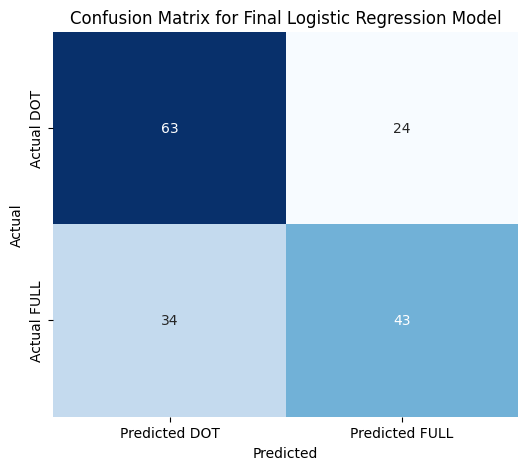

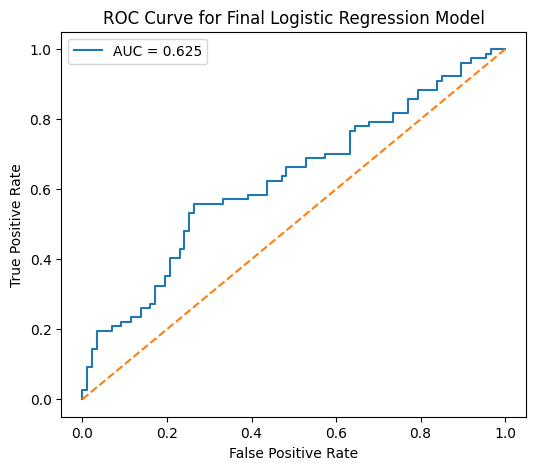


Top 20 most influential features:


,feature_name,coefficient,absolute_coefficient
104,cat__pres_lens_long_le_categories_Mild Myopia,-1.197992,1.197992
147,cat__dot_time_taken_minutes_22,1.082545,1.082545
119,cat__pupillary_distance_categories_Missing,1.048226,1.048226
99,cat__pres_lens_long_re_categories_Moderate Myopia,-1.001995,1.001995
86,cat__screening_va_ldu_re_logmar_1.1,-0.843196,0.843196
124,cat__pupillary_distance_categories_Step 4 – Ve...,-0.725476,0.725476
136,cat__dot_time_taken_minutes_13,-0.708945,0.708945
69,cat__screening_va_ldu_re_logmar_ 6/24,-0.705668,0.705668
65,cat__age_categories_Teenagers,-0.626809,0.626809
103,cat__pres_lens_long_le_categories_Medium Add,0.570238,0.570238


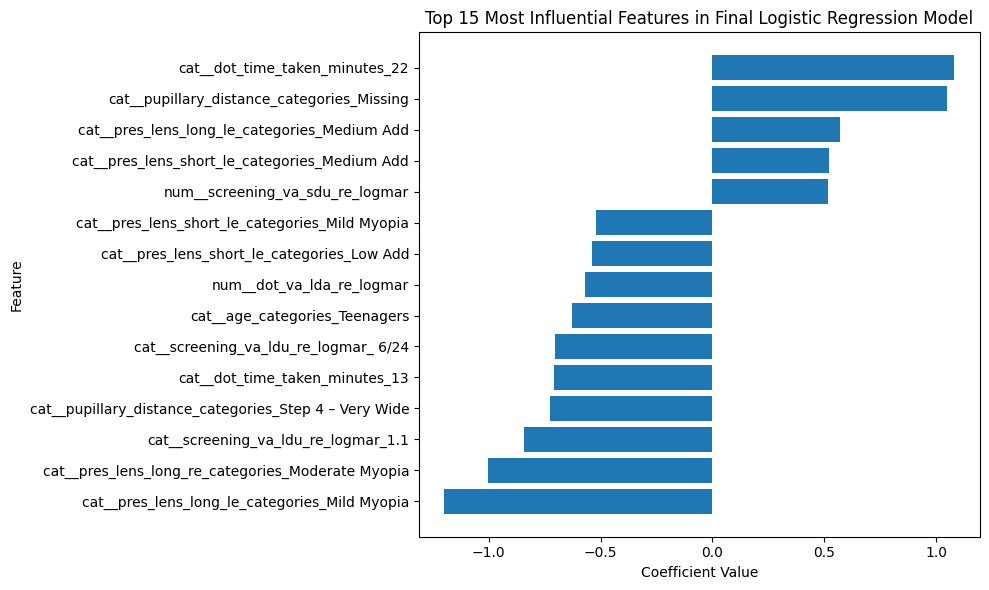

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Retaining only the rows with valid target labels
final_df = merged_df[merged_df["final_prescription"].notna()].copy()

# Standardizing the target labels again for safety
final_df["final_prescription"] = (
    final_df["final_prescription"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Retaining only the valid target classes
final_df = final_df[final_df["final_prescription"].isin(["DOT", "FULL"])].copy()

# Defining the predictor matrix and target vector
excluded_columns = ["coding", "final_prescription"]
X_final = final_df.drop(columns=excluded_columns).copy()
y_final = final_df["final_prescription"].map({"DOT": 0, "FULL": 1})

# Identifying the numerical and categorical predictor columns
numerical_columns_final = X_final.select_dtypes(include=["number"]).columns.tolist()
categorical_columns_final = X_final.select_dtypes(exclude=["number"]).columns.tolist()

# Building the final preprocessing pipeline
numerical_transformer_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("to_string", FunctionTransformer(lambda x: x.astype(str), feature_names_out='one-to-one')),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

final_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer_final, numerical_columns_final),
        ("cat", categorical_transformer_final, categorical_columns_final)
    ]
)

# Splitting the data into training and testing sets
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

print("Training predictor shape:", X_train_final.shape)
print("Testing predictor shape:", X_test_final.shape)
print("Training target shape:", y_train_final.shape)
print("Testing target shape:", y_test_final.shape)

# Defining the final logistic regression model
final_logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# Building the final modeling pipeline
final_logistic_pipeline = Pipeline(steps=[
    ("preprocessor", final_preprocessor),
    ("classifier", final_logistic_model)
])

# Training the final model
final_logistic_pipeline.fit(X_train_final, y_train_final)

# Generating the predictions
y_pred_final = final_logistic_pipeline.predict(X_test_final)
y_prob_final = final_logistic_pipeline.predict_proba(X_test_final)[:, 1]

# Computing the final evaluation metrics
final_metrics_df = pd.DataFrame([{
    "Model": "Final Logistic Regression",
    "Accuracy": accuracy_score(y_test_final, y_pred_final),
    "Precision": precision_score(y_test_final, y_pred_final),
    "Recall": recall_score(y_test_final, y_pred_final),
    "F1 Score": f1_score(y_test_final, y_pred_final),
    "ROC AUC": roc_auc_score(y_test_final, y_prob_final)
}])

print("\nFinal logistic regression performance:")
display(final_metrics_df)

# Printing the confusion matrix
cm_final = confusion_matrix(y_test_final, y_pred_final)

print("\nConfusion Matrix:")
print(cm_final)

# Printing the classification report
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_final, target_names=["DOT", "FULL"]))

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted DOT", "Predicted FULL"],
            yticklabels=["Actual DOT", "Actual FULL"])
plt.title("Confusion Matrix for Final Logistic Regression Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Plotting the ROC curve
fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
auc_score = roc_auc_score(y_test_final, y_prob_final)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve for Final Logistic Regression Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Extracting the processed feature names
processed_feature_names_final = final_logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Extracting the logistic regression coefficients
coefficients_final = final_logistic_pipeline.named_steps["classifier"].coef_[0]

coefficient_table = pd.DataFrame({
    "feature_name": processed_feature_names_final,
    "coefficient": coefficients_final,
    "absolute_coefficient": np.abs(coefficients_final)
}).sort_values(by="absolute_coefficient", ascending=False)

print("\nTop 20 most influential features:")
display(coefficient_table.head(20))

# Plotting the top 15 most influential features
top_features = coefficient_table.head(15).sort_values(by="coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature_name"], top_features["coefficient"])
plt.title("Top 15 Most Influential Features in Final Logistic Regression Model")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The final logistic regression model confirms the same overall pattern observed in the earlier experiments. Its performance is moderate rather than strong, with an accuracy of about 64.6%, a precision of about 64.2%, a recall of about 55.8%, an F1-score of about 59.7%, and an ROC-AUC of about 62.5%. This means the model is learning some useful signal from the data, but the separation between the `DOT` and `FULL` classes is still only moderate.

The confusion matrix shows that the model performs better on the `DOT` class than on the `FULL` class. It correctly classifies 63 `DOT` cases and 43 `FULL` cases, but it still misclassifies 24 `DOT` cases as `FULL` and 34 `FULL` cases as `DOT`. This is consistent with the classification report, where the `DOT` class has slightly stronger recall and F1-score than the `FULL` class. In practical terms, the model is somewhat more reliable at identifying participants who should remain in the `DOT` pathway than those who should be referred to `FULL`.

The coefficient output also shows that the model is being driven by a mixture of prescription category variables, pupillary distance information, selected screening values, DOT visual acuity measures, and some timing-related variables. This suggests that the recommendation decision is not being explained by one single factor, but by a combination of clinical and process-related features.

The final logistic regression results show that the model achieved moderate predictive performance. It recorded an accuracy of 64.6%, a precision of 64.2%, a recall of 55.8%, an F1-score of 59.7%, and an ROC-AUC of 62.5%. These results indicate that the model was able to learn meaningful patterns from the available data, but the distinction between participants recommended for `DOT` and those recommended for `FULL` was not very strong.

The confusion matrix shows that the model performed slightly better in identifying `DOT` cases than `FULL` cases. It correctly classified 63 `DOT` cases and 43 `FULL` cases, while 24 `DOT` cases were classified as `FULL` and 34 `FULL` cases were classified as `DOT`. This pattern is also reflected in the classification report, where the `DOT` class achieved a stronger recall and F1-score than the `FULL` class.

The coefficient output suggests that the model’s predictions were influenced by a combination of prescription-related variables, pupillary distance information, selected screening measures, DOT visual acuity measures, and some timing-related variables. This means that the recommendation pathway was shaped by multiple clinical and process factors rather than by a single dominant predictor.

Overall, logistic regression was retained as the final model because it consistently performed better than the other models tested and produced the most stable results.

## Step 13: Saving the Final Model and Preparing It for Prediction

With logistic regression now selected as the final model, the next task is packaging it as the implementation artifact. This is important because the project is not ending at model comparison; it is ending with a usable recommendation system. At this stage, the trained preprocessing pipeline and the final classifier are being saved so that they can be reused without retraining from scratch. A simple prediction function is also being created so that new participant records can be passed through the saved pipeline and returned as either `DOT` or `FULL` together with the corresponding probability scores. Completing this step makes the implementation complete, reproducible, and ready for demonstration and documentation.

In [ ]:
import joblib
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Define a named function to convert to string, replacing the lambda
def _to_string(x):
    return x.astype(str)

# Rebuilding the final modeling dataset
final_df = merged_df[merged_df["final_prescription"].notna()].copy()

# Standardizing the target labels again for safety
final_df["final_prescription"] = (
    final_df["final_prescription"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Retaining only the valid target classes
final_df = final_df[final_df["final_prescription"].isin(["DOT", "FULL"])].copy()

# Defining the predictor matrix and target vector
excluded_columns = ["coding", "final_prescription"]
X_final = final_df.drop(columns=excluded_columns).copy()
y_final = final_df["final_prescription"].map({"DOT": 0, "FULL": 1})

# Identifying the numerical and categorical predictor columns
numerical_columns_final = X_final.select_dtypes(include=["number"]).columns.tolist()
categorical_columns_final = X_final.select_dtypes(exclude=["number"]).columns.tolist()

# Rebuilding the final preprocessing pipeline
numerical_transformer_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("to_string", FunctionTransformer(_to_string, feature_names_out='one-to-one')),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

final_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer_final, numerical_columns_final),
        ("cat", categorical_transformer_final, categorical_columns_final)
    ]
)

# Splitting the data in the same way as before
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

# Defining the final logistic regression model
final_logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# Building and training the final pipeline
final_logistic_pipeline = Pipeline(steps=[
    ("preprocessor", final_preprocessor),
    ("classifier", final_logistic_model)
])

final_logistic_pipeline.fit(X_train_final, y_train_final)

# Saving the trained pipeline
joblib.dump(final_logistic_pipeline, "final_logistic_pipeline.pkl")

# Saving the feature column order
joblib.dump(X_final.columns.tolist(), "final_feature_columns.pkl")

print("Final logistic regression pipeline saved as 'final_logistic_pipeline.pkl'")
print("Feature column list saved as 'final_feature_columns.pkl'")

# Creating a reusable prediction function
def predict_recommendation(input_df, pipeline, expected_columns):
    input_df = input_df.copy()

    # Adding any missing columns
    for col in expected_columns:
        if col not in input_df.columns:
            input_df[col] = np.nan

    # Reordering the columns to match the training data
    input_df = input_df[expected_columns]

    # Generating the prediction and probabilities
    predicted_class = pipeline.predict(input_df)[0]
    predicted_probabilities = pipeline.predict_proba(input_df)[0]

    # Mapping the prediction back to class labels
    class_mapping = {0: "DOT", 1: "FULL"}
    predicted_label = class_mapping[predicted_class]

    result = {
        "predicted_class": predicted_label,
        "probability_dot": predicted_probabilities[0],
        "probability_full": predicted_probabilities[1]
    }

    return result

# Demonstrating the prediction function with one example row from the test set
example_input = X_test_final.iloc[[0]].copy()

example_result = predict_recommendation(
    input_df=example_input,
    pipeline=final_logistic_pipeline,
    expected_columns=X_final.columns.tolist()
)

print("\nExample prediction result:")
print(example_result)

Final logistic regression pipeline saved as 'final_logistic_pipeline.pkl'
Feature column list saved as 'final_feature_columns.pkl'

Example prediction result:
{'predicted_class': 'FULL', 'probability_dot': np.float64(0.29898635892803727), 'probability_full': np.float64(0.7010136410719627)}


The final model and preprocessing pipeline have been saved successfully, which means the implementation artifact is now complete and reusable. The saved pipeline file preserves both the preprocessing steps and the trained logistic regression model, while the feature column file preserves the exact predictor structure expected during future predictions. This is important because it allows the recommendation system to be used again without rebuilding the entire workflow from the beginning.

The example prediction confirms that the saved model is functioning correctly. For the sample participant passed into the prediction function, the model returned `FULL` as the recommended pathway, with an estimated probability of about 70.1% for `FULL` and 29.9% for `DOT`. This shows that the system is not only capable of producing a class label, but can also provide the probability scores behind the decision. That makes the artifact more informative and suitable for demonstration, interpretation, and later reporting.



## Step 14: Exporting the Final Outputs for Documentation

With the final model now saved and ready for prediction, the next task is preparing the main outputs that will support the reporting of the implementation. These outputs include the final performance metrics, the confusion matrix, the ROC curve, and the coefficient table. Saving them at this stage is important because it creates a clean record of the final model results and makes it easier to use the same tables and figures consistently in the write-up. This step therefore bridges the coding phase and the documentation phase by organizing the evidence that will be reported in the findings section.

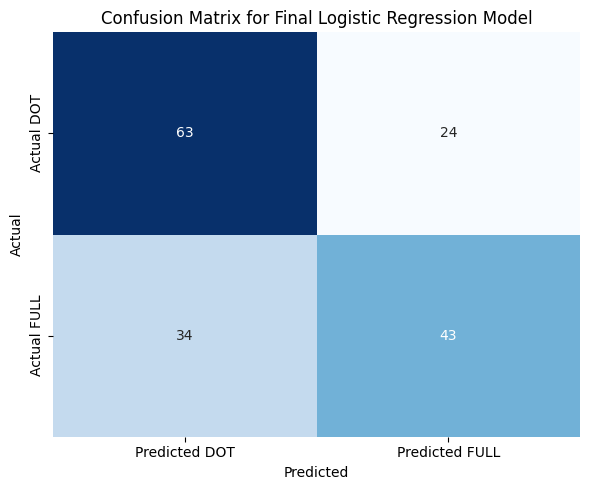

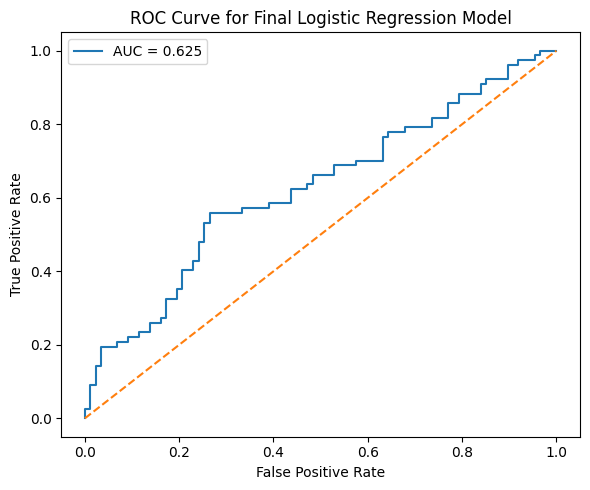

Saved files:
- final_model_outputs/final_metrics.csv
- final_model_outputs/confusion_matrix.csv
- final_model_outputs/confusion_matrix_plot.png
- final_model_outputs/roc_curve_data.csv
- final_model_outputs/roc_curve_plot.png
- final_model_outputs/coefficient_table.csv

Final metrics preview:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Final Logistic Regression,0.646341,0.641791,0.558442,0.597222,0.624869



Top 15 coefficient rows:


,feature_name,coefficient,absolute_coefficient
104,cat__pres_lens_long_le_categories_Mild Myopia,-1.197992,1.197992
147,cat__dot_time_taken_minutes_22,1.082545,1.082545
119,cat__pupillary_distance_categories_Missing,1.048226,1.048226
99,cat__pres_lens_long_re_categories_Moderate Myopia,-1.001995,1.001995
86,cat__screening_va_ldu_re_logmar_1.1,-0.843196,0.843196
124,cat__pupillary_distance_categories_Step 4 – Ve...,-0.725476,0.725476
136,cat__dot_time_taken_minutes_13,-0.708945,0.708945
69,cat__screening_va_ldu_re_logmar_ 6/24,-0.705668,0.705668
65,cat__age_categories_Teenagers,-0.626809,0.626809
103,cat__pres_lens_long_le_categories_Medium Add,0.570238,0.570238


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Creating an output folder for the final results
output_dir = "final_model_outputs"
os.makedirs(output_dir, exist_ok=True)

# Rebuilding the final evaluation predictions
y_pred_final = final_logistic_pipeline.predict(X_test_final)
y_prob_final = final_logistic_pipeline.predict_proba(X_test_final)[:, 1]

# Creating the final metrics table
final_metrics_df = pd.DataFrame([{
    "Model": "Final Logistic Regression",
    "Accuracy": accuracy_score(y_test_final, y_pred_final),
    "Precision": precision_score(y_test_final, y_pred_final),
    "Recall": recall_score(y_test_final, y_pred_final),
    "F1 Score": f1_score(y_test_final, y_pred_final),
    "ROC AUC": roc_auc_score(y_test_final, y_prob_final)
}])

# Saving the final metrics table
final_metrics_path = os.path.join(output_dir, "final_metrics.csv")
final_metrics_df.to_csv(final_metrics_path, index=False)

# Creating and saving the confusion matrix
cm_final = confusion_matrix(y_test_final, y_pred_final)

cm_df = pd.DataFrame(
    cm_final,
    index=["Actual DOT", "Actual FULL"],
    columns=["Predicted DOT", "Predicted FULL"]
)

confusion_matrix_path = os.path.join(output_dir, "confusion_matrix.csv")
cm_df.to_csv(confusion_matrix_path)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for Final Logistic Regression Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
confusion_matrix_plot_path = os.path.join(output_dir, "confusion_matrix_plot.png")
plt.savefig(confusion_matrix_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# Creating and saving the ROC curve
fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
auc_score = roc_auc_score(y_test_final, y_prob_final)

roc_df = pd.DataFrame({
    "False Positive Rate": fpr,
    "True Positive Rate": tpr,
    "Threshold": thresholds
})

roc_data_path = os.path.join(output_dir, "roc_curve_data.csv")
roc_df.to_csv(roc_data_path, index=False)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve for Final Logistic Regression Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
roc_plot_path = os.path.join(output_dir, "roc_curve_plot.png")
plt.savefig(roc_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# Creating and saving the coefficient table
processed_feature_names_final = final_logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients_final = final_logistic_pipeline.named_steps["classifier"].coef_[0]

coefficient_table = pd.DataFrame({
    "feature_name": processed_feature_names_final,
    "coefficient": coefficients_final,
    "absolute_coefficient": abs(coefficients_final)
}).sort_values(by="absolute_coefficient", ascending=False)

coefficient_table_path = os.path.join(output_dir, "coefficient_table.csv")
coefficient_table.to_csv(coefficient_table_path, index=False)

# Previewing the saved outputs
print("Saved files:")
print("-", final_metrics_path)
print("-", confusion_matrix_path)
print("-", confusion_matrix_plot_path)
print("-", roc_data_path)
print("-", roc_plot_path)
print("-", coefficient_table_path)

print("\nFinal metrics preview:")
display(final_metrics_df)

print("\nTop 15 coefficient rows:")
display(coefficient_table.head(15))